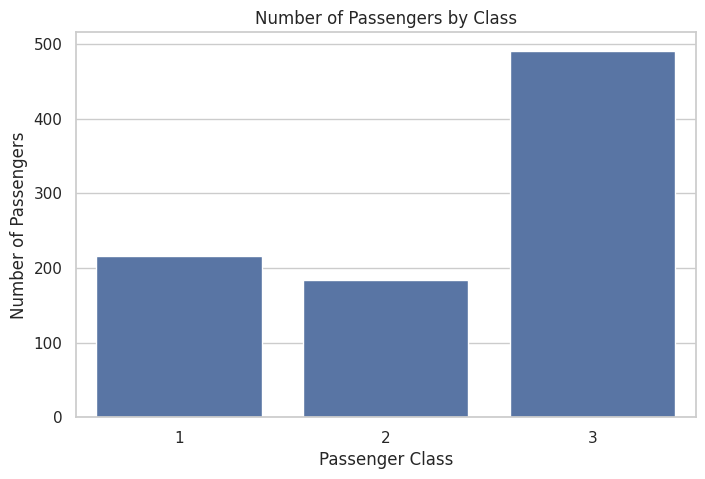

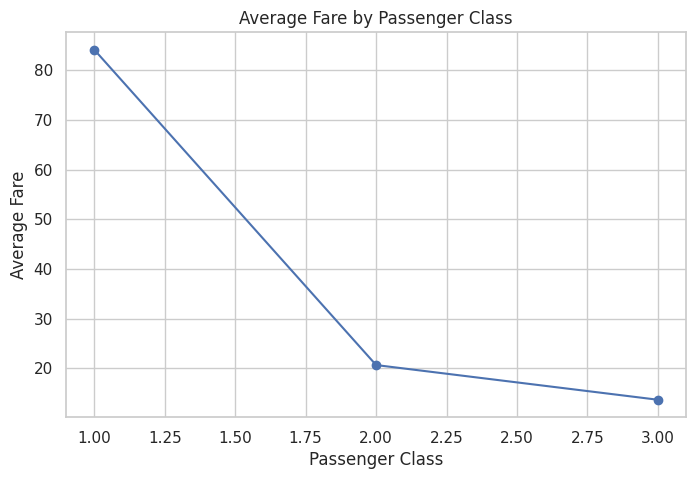

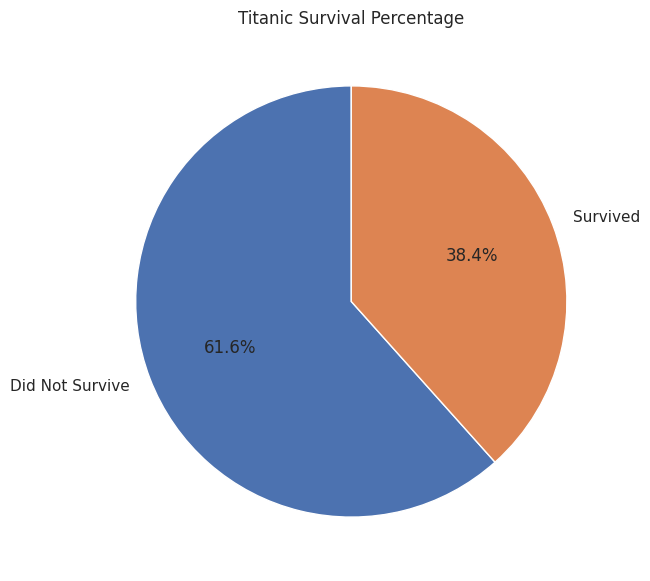

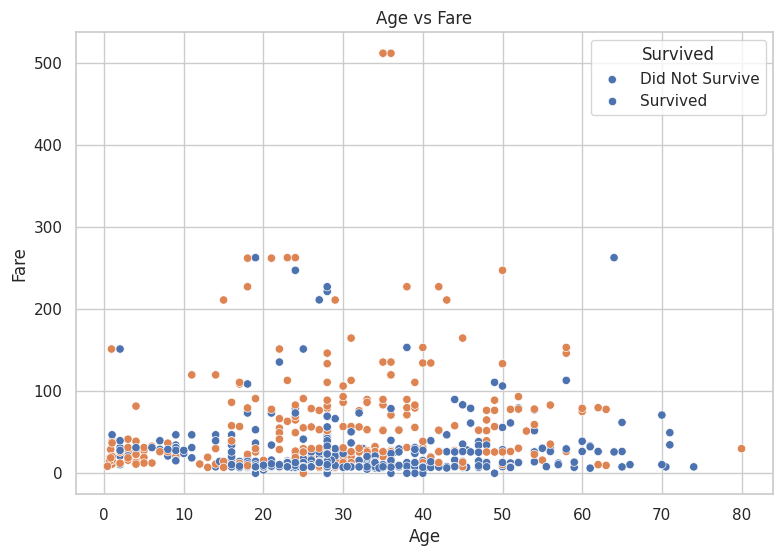

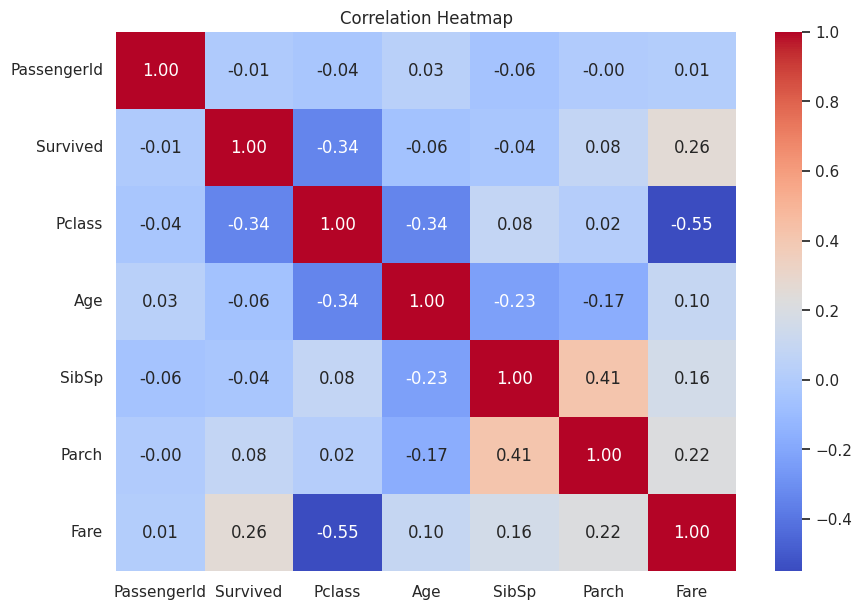

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# =================================================
# TASK 3: DATA VISUALIZATION DASHBOARD
# =================================================
# Load any public dataset (CSV format).
sns.set_theme(style="whitegrid")
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Handle missing values needed for visualization
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

# CHART 1: BAR CHART
# Count the number of passengers in each passenger class.
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Pclass"
)
plt.title("Number of Passengers by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()


# CHART 2: LINE CHART
# Calculate the average fare for each passenger class.
average_fare = df.groupby("Pclass")["Fare"].mean()
plt.figure(figsize=(8, 5))
plt.plot(
    average_fare.index,
    average_fare.values,
    marker="o"
)
plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.grid(True)
plt.show()


#  CHART 3: PIE CHART
# Count the number of passengers who survived and did not survive.
survival_counts = df["Survived"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Titanic Survival Percentage")
plt.show()


# CHART 4: SCATTER PLOT
# Show the relationship between Age and Fare.
# The color represents survival status.
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(
    title="Survived",
    labels=["Did Not Survive", "Survived"]
)

plt.show()


# CHART 5: HEATMAP
# Select numerical columns.
numeric_df = df.select_dtypes(
    include=np.number
)

# Calculate correlations.
correlation = numeric_df.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()


# ============================================================
# BONUS: INTERACTIVE PLOTLY DASHBOARD
# ============================================================
# Interactive Bar Chart
fig1 = px.bar(
    df,
    x="Pclass",
    color="Survived",
    title="Passengers by Class and Survival",
    labels={
        "Pclass": "Passenger Class",
        "Survived": "Survived"
    }
)
fig1.show()

# Interactive Line Chart
line_data = df.groupby(
    "Pclass",
    as_index=False
)["Fare"].mean()

fig2 = px.line(
    line_data,
    x="Pclass",
    y="Fare",
    markers=True,
    title="Average Fare by Passenger Class",
    labels={
        "Pclass": "Passenger Class",
        "Fare": "Average Fare"
    }
)

fig2.show()

# Interactive Pie Chart
survival_data = (
    df["Survived"]
    .value_counts()
    .reset_index()
)

survival_data.columns = [
    "Survived",
    "Count"
]

fig3 = px.pie(
    survival_data,
    names="Survived",
    values="Count",
    title="Survival Distribution"
)

fig3.show()

# Interactive Scatter Plot
fig4 = px.scatter(
    df,
    x="Age",
    y="Fare",
    color="Survived",
    hover_data=[
        "Sex",
        "Pclass",
        "Embarked"
    ],
    title="Age vs Fare"
)
fig4.show()

# Interactive Heatmap
fig5 = px.imshow(
    correlation,
    text_auto=True,
    title="Interactive Correlation Heatmap"
)

fig5.show()
